In [1]:
import pandas as pd
import numpy as np

In [4]:
# loading the dataset
df = pd.read_csv('../data/vendor_proposals.csv')

print("Shape:", df.shape)
df.head()

Shape: (400, 14)


,vendor_id,unit_price,delivery_days,quality_score,vendor_experience_years,defect_rate_percent,support_rating,on_time_delivery_rate,certifications_count,payment_terms_days,warranty_months,vendor_region,product_category,vendor_score
0,V001,17438.551752,50,5.048068,7,9.170229,3.316414,0.616139,1,60,48,Asia,Machinery,39.151198
1,V002,11642.490226,31,5.187937,20,5.649623,4.716415,0.730431,3,30,6,Asia,Electronics,55.698837
2,V003,30002.126234,60,6.931918,29,3.362569,3.808015,1.000000,6,90,0,North America,Machinery,70.394966
3,V004,14056.279160,39,4.143486,15,7.660778,3.719722,0.778616,2,45,6,Local,Electronics,52.144840
4,V005,15950.910749,61,5.757306,11,6.685910,2.337368,0.705931,2,90,24,Europe,Raw Materials,45.579906


In [5]:
df.dtypes


vendor_id                      str
unit_price                 float64
delivery_days                int64
quality_score              float64
vendor_experience_years      int64
defect_rate_percent        float64
support_rating             float64
on_time_delivery_rate      float64
certifications_count         int64
payment_terms_days           int64
warranty_months              int64
vendor_region                  str
product_category               str
vendor_score               float64
dtype: object

In [6]:
df.describe()

,unit_price,delivery_days,quality_score,vendor_experience_years,defect_rate_percent,support_rating,on_time_delivery_rate,certifications_count,payment_terms_days,warranty_months,vendor_score
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,22000.781852,43.510000,5.738499,15.895000,6.887989,3.286154,0.763858,3.320000,61.387500,26.520000,50.201699
std,7168.231829,15.127028,1.976747,9.231306,2.297255,0.992121,0.145305,2.387856,35.170724,20.000241,14.813801
min,2111.502546,1.000000,1.210854,1.000000,0.465720,1.000000,0.500000,0.000000,15.000000,0.000000,21.055333
25%,16303.501351,32.000000,4.245356,7.750000,5.408389,2.621556,0.652267,1.000000,30.000000,6.000000,38.927527
50%,22496.005547,44.000000,5.819972,16.000000,6.937495,3.297124,0.777839,3.000000,60.000000,24.000000,50.546432
75%,27403.500282,54.000000,7.232173,24.000000,8.542666,4.079041,0.871350,5.000000,90.000000,48.000000,62.443942
max,38787.928628,82.000000,10.000000,30.000000,12.356665,5.000000,1.000000,9.000000,120.000000,60.000000,83.484274


In [7]:
df.isnull().sum()

vendor_id                  0
unit_price                 0
delivery_days              0
quality_score              0
vendor_experience_years    0
defect_rate_percent        0
support_rating             0
on_time_delivery_rate      0
certifications_count       0
payment_terms_days         0
warranty_months            0
vendor_region              0
product_category           0
vendor_score               0
dtype: int64

In [10]:
# Data cleaning
# Drop ID
df_clean = df.drop(columns=['vendor_id'])

# check duplicates 
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [12]:
# check negative values
numeric_cols = df_clean.select_dtypes(include=np.number).columns
print((df_clean[numeric_cols] < 0).sum())

# Clip values to valid ranges
df_clean['vendor_score'] = df_clean['vendor_score'].clip(0, 100)
df_clean['quality_score'] = df_clean['quality_score'].clip(1, 10)

unit_price                 0
delivery_days              0
quality_score              0
vendor_experience_years    0
defect_rate_percent        0
support_rating             0
on_time_delivery_rate      0
certifications_count       0
payment_terms_days         0
warranty_months            0
vendor_score               0
dtype: int64


In [13]:
print("Cleaning done. Shape:", df_clean.shape)


Cleaning done. Shape: (400, 13)


In [14]:
# Feature engineering
# 1. Price to Quality Ratio
df_clean['price_quality_ratio'] = df_clean['unit_price'] / df_clean['quality_score']

# 2. Reliability Index
df_clean['reliability_index'] = (
    df_clean['on_time_delivery_rate'] *
    (1 - df_clean['defect_rate_percent'] / 100)
)

# 3. Vendor Maturity
df_clean['vendor_maturity'] = (
    df_clean['vendor_experience_years'] * 0.7 +
    df_clean['certifications_count'] * 1.5
)

# 4. Premium Vendor Flag
price_threshold = df_clean['unit_price'].quantile(0.60)

df_clean['is_premium'] = (
    (df_clean['quality_score'] > 7) &
    (df_clean['unit_price'] > price_threshold)
).astype(int)

df_clean.head()

,unit_price,delivery_days,quality_score,vendor_experience_years,defect_rate_percent,support_rating,on_time_delivery_rate,certifications_count,payment_terms_days,warranty_months,vendor_region,product_category,vendor_score,price_quality_ratio,reliability_index,vendor_maturity,is_premium
0,17438.551752,50,5.048068,7,9.170229,3.316414,0.616139,1,60,48,Asia,Machinery,39.151198,3454.500205,0.559637,6.4,0
1,11642.490226,31,5.187937,20,5.649623,4.716415,0.730431,3,30,6,Asia,Electronics,55.698837,2244.146581,0.689165,18.5,0
2,30002.126234,60,6.931918,29,3.362569,3.808015,1.000000,6,90,0,North America,Machinery,70.394966,4328.113248,0.966374,29.3,0
3,14056.279160,39,4.143486,15,7.660778,3.719722,0.778616,2,45,6,Local,Electronics,52.144840,3392.379754,0.718968,13.5,0
4,15950.910749,61,5.757306,11,6.685910,2.337368,0.705931,2,90,24,Europe,Raw Materials,45.579906,2770.551069,0.658733,10.7,0


In [15]:
# verify new features
df_clean.describe()

,unit_price,delivery_days,quality_score,vendor_experience_years,defect_rate_percent,support_rating,on_time_delivery_rate,certifications_count,payment_terms_days,warranty_months,vendor_score,price_quality_ratio,reliability_index,vendor_maturity,is_premium
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.0000
mean,22000.781852,43.510000,5.738499,15.895000,6.887989,3.286154,0.763858,3.320000,61.387500,26.520000,50.201699,3987.872212,0.713112,16.106500,0.2475
std,7168.231829,15.127028,1.976747,9.231306,2.297255,0.992121,0.145305,2.387856,35.170724,20.000241,14.813801,1059.539804,0.145795,9.633737,0.4321
min,2111.502546,1.000000,1.210854,1.000000,0.465720,1.000000,0.500000,0.000000,15.000000,0.000000,21.055333,1096.697960,0.441433,0.700000,0.0000
25%,16303.501351,32.000000,4.245356,7.750000,5.408389,2.621556,0.652267,1.000000,30.000000,6.000000,38.927527,3357.022065,0.599228,7.100000,0.0000
50%,22496.005547,44.000000,5.819972,16.000000,6.937495,3.297124,0.777839,3.000000,60.000000,24.000000,50.546432,3869.265306,0.719689,16.400000,0.0000
75%,27403.500282,54.000000,7.232173,24.000000,8.542666,4.079041,0.871350,5.000000,90.000000,48.000000,62.443942,4399.953381,0.824939,24.900000,0.0000
max,38787.928628,82.000000,10.000000,30.000000,12.356665,5.000000,1.000000,9.000000,120.000000,60.000000,83.484274,10169.746687,0.993237,34.500000,1.0000


In [17]:
# Data Preprocessing
# Split target and input 
X = df_clean.drop(columns=['vendor_score'])
y = df_clean['vendor_score']

print(X.shape, y.shape)


(400, 16) (400,)


In [21]:
X = pd.get_dummies(X, columns=['vendor_region', 'product_category'], drop_first=True)

X.head()

KeyError: "None of [Index(['vendor_region', 'product_category'], dtype='str')] are in the [columns]"

In [22]:
X.head()

,unit_price,delivery_days,quality_score,vendor_experience_years,defect_rate_percent,support_rating,on_time_delivery_rate,certifications_count,payment_terms_days,warranty_months,...,reliability_index,vendor_maturity,is_premium,vendor_region_Europe,vendor_region_Local,vendor_region_North America,product_category_IT Services,product_category_Machinery,product_category_Packaging,product_category_Raw Materials
0,17438.551752,50,5.048068,7,9.170229,3.316414,0.616139,1,60,48,...,0.559637,6.4,0,False,False,False,False,True,False,False
1,11642.490226,31,5.187937,20,5.649623,4.716415,0.730431,3,30,6,...,0.689165,18.5,0,False,False,False,False,False,False,False
2,30002.126234,60,6.931918,29,3.362569,3.808015,1.000000,6,90,0,...,0.966374,29.3,0,False,False,True,False,True,False,False
3,14056.279160,39,4.143486,15,7.660778,3.719722,0.778616,2,45,6,...,0.718968,13.5,0,False,True,False,False,False,False,False
4,15950.910749,61,5.757306,11,6.685910,2.337368,0.705931,2,90,24,...,0.658733,10.7,0,True,False,False,False,False,False,True


In [23]:
X = X.astype(int)

In [24]:
X.head()

,unit_price,delivery_days,quality_score,vendor_experience_years,defect_rate_percent,support_rating,on_time_delivery_rate,certifications_count,payment_terms_days,warranty_months,...,reliability_index,vendor_maturity,is_premium,vendor_region_Europe,vendor_region_Local,vendor_region_North America,product_category_IT Services,product_category_Machinery,product_category_Packaging,product_category_Raw Materials
0,17438,50,5,7,9,3,0,1,60,48,...,0,6,0,0,0,0,0,1,0,0
1,11642,31,5,20,5,4,0,3,30,6,...,0,18,0,0,0,0,0,0,0,0
2,30002,60,6,29,3,3,1,6,90,0,...,0,29,0,0,0,1,0,1,0,0
3,14056,39,4,15,7,3,0,2,45,6,...,0,13,0,0,1,0,0,0,0,0
4,15950,61,5,11,6,2,0,2,90,24,...,0,10,0,1,0,0,0,0,0,1


In [27]:
# split into test and training data 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (320, 21)
Test: (80, 21)


In [28]:
# feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_features = X.select_dtypes(include=np.number).columns.tolist()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features]  = scaler.transform(X_test[numeric_features])

print("Scaling done")

Scaling done


In [29]:
X_train.head()

,unit_price,delivery_days,quality_score,vendor_experience_years,defect_rate_percent,support_rating,on_time_delivery_rate,certifications_count,payment_terms_days,warranty_months,...,reliability_index,vendor_maturity,is_premium,vendor_region_Europe,vendor_region_Local,vendor_region_North America,product_category_IT Services,product_category_Machinery,product_category_Packaging,product_category_Raw Materials
3,-1.117503,-0.334261,-0.605000,-0.082265,0.286060,0.213896,-0.251243,-0.552286,-0.449616,-1.045995,...,0.0,-0.266621,-0.5581,-0.562914,1.807392,-0.654654,-0.504878,-0.445535,-0.5,-0.509748
18,0.373012,-0.811168,-0.109859,0.909044,0.286060,0.213896,-0.251243,1.111069,1.691412,1.076314,...,0.0,0.984998,-0.5581,-0.562914,1.807392,-0.654654,-0.504878,-0.445535,-0.5,-0.509748
202,0.450423,-1.492463,-0.109859,-0.082265,0.286060,0.213896,-0.251243,-0.136447,-1.306027,-1.349182,...,0.0,-0.058018,-0.5581,1.776470,-0.553283,-0.654654,-0.504878,-0.445535,-0.5,-0.509748
250,-2.638678,2.186533,-2.090422,-1.624301,1.569322,-1.741727,-0.251243,-1.383963,1.691412,-1.045995,...,0.0,-1.622541,-0.5581,-0.562914,-0.553283,1.527525,-0.504878,-0.445535,2.0,-0.509748
274,0.086673,-0.198002,0.385281,0.909044,-0.569447,1.191708,-0.251243,0.695230,0.835001,1.076314,...,0.0,0.880696,-0.5581,-0.562914,-0.553283,1.527525,-0.504878,-0.445535,-0.5,1.961756


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

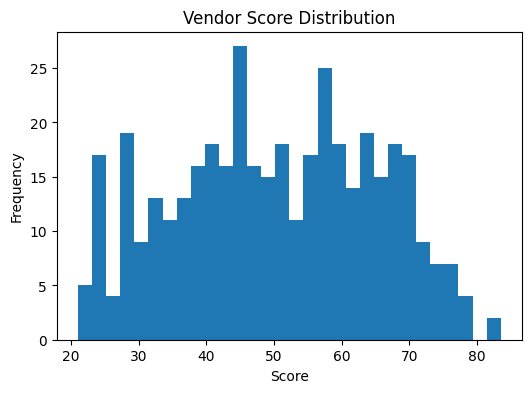

In [31]:
plt.figure(figsize=(6,4))
plt.hist(df_clean['vendor_score'], bins=30)
plt.title("Vendor Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

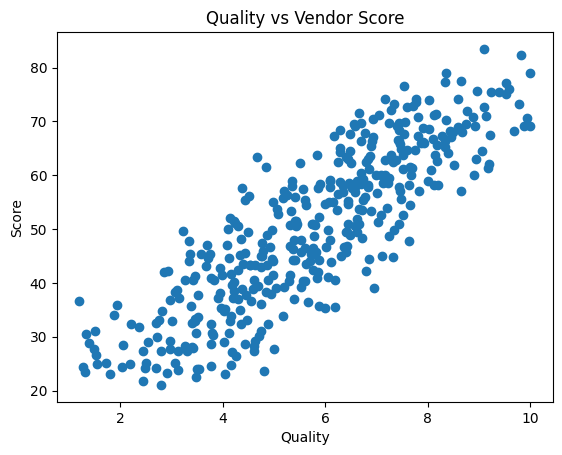

In [32]:
plt.scatter(df_clean['quality_score'], df_clean['vendor_score'])
plt.title("Quality vs Vendor Score")
plt.xlabel("Quality")
plt.ylabel("Score")
plt.show()

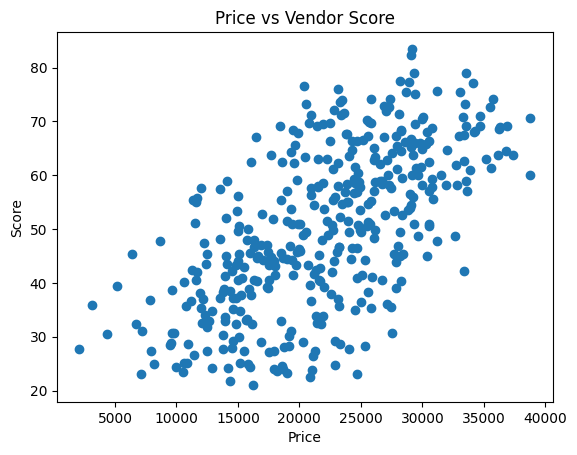

In [33]:
plt.scatter(df_clean['unit_price'], df_clean['vendor_score'])
plt.title("Price vs Vendor Score")
plt.xlabel("Price")
plt.ylabel("Score")
plt.show()


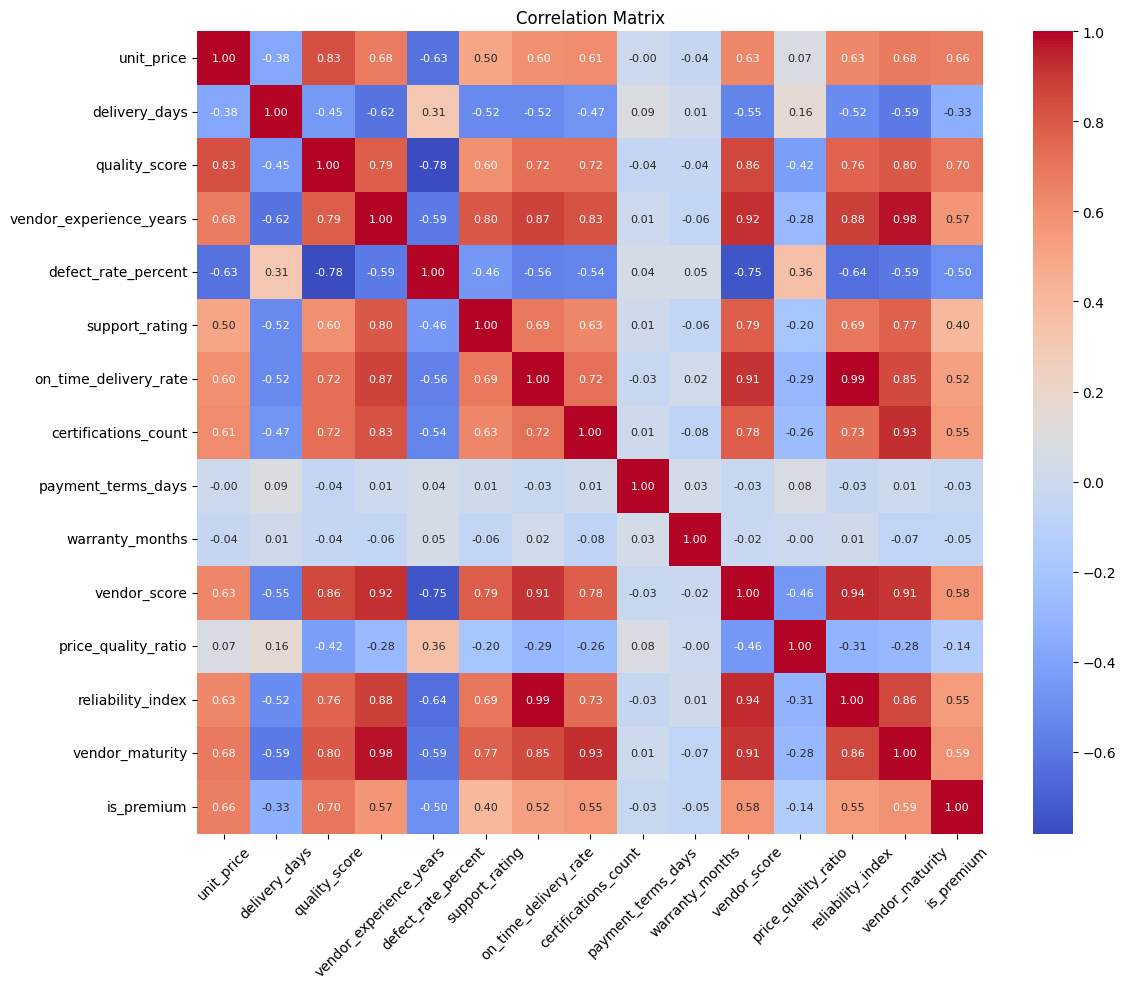

In [35]:
plt.figure(figsize=(12,10))

corr = df_clean.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    annot_kws={"size": 8}   # smaller text
)

plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

In [40]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
# import models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math

In [42]:
# define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        n_jobs=-1
    )
}

In [45]:
# training and evaluating
import time 
results = {}
trained_models = {}

for name, model in models.items():
    
    start_time = time.time()
    model.fit(X_train, y_train)
    elapsed_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results[name] = {
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "Time (s)": elapsed_time
    }
    
    trained_models[name] = model
    
    print(f"{name}")
    print(f"R2: {r2:.4f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}")
    print("-"*40)

Linear Regression
R2: 0.9417, RMSE: 3.62, MAE: 2.96
----------------------------------------
Ridge Regression
R2: 0.9413, RMSE: 3.64, MAE: 2.97
----------------------------------------
Random Forest
R2: 0.9133, RMSE: 4.42, MAE: 3.64
----------------------------------------
Gradient Boosting
R2: 0.9248, RMSE: 4.12, MAE: 3.43
----------------------------------------
XGBoost
R2: 0.9205, RMSE: 4.23, MAE: 3.56
----------------------------------------


In [46]:
# compare models

results_df = pd.DataFrame(results).T.sort_values(by="R2", ascending=False)

print(results_df)

                         R2      RMSE       MAE  Time (s)
Linear Regression  0.941730  3.624279  2.957212  0.014174
Ridge Regression   0.941350  3.636085  2.971883  0.049517
Gradient Boosting  0.924804  4.117140  3.430496  0.462009
XGBoost            0.920466  4.234247  3.560888  0.316128
Random Forest      0.913307  4.420701  3.641101  1.105294


In [47]:
# select best model
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Linear Regression


In [48]:
# Use best model from previous step
y_pred = best_model.predict(X_test)

print("Predictions generated:", len(y_pred))

Predictions generated: 80


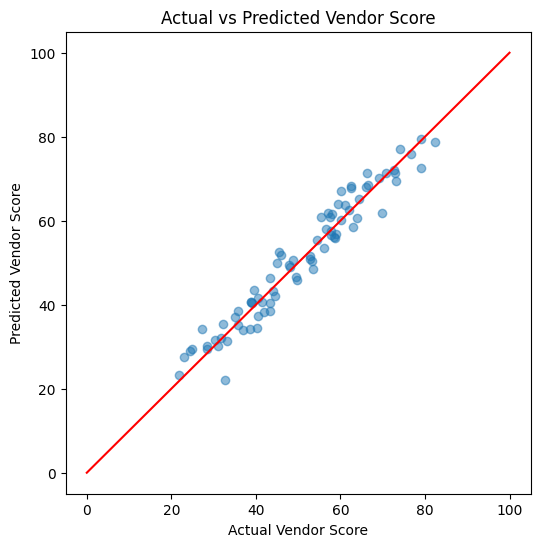

In [49]:
# Actual vs Predicted plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction line
plt.plot([0, 100], [0, 100], color='red')

plt.xlabel("Actual Vendor Score")
plt.ylabel("Predicted Vendor Score")
plt.title("Actual vs Predicted Vendor Score")

plt.show()

In [50]:
# vendor ranking system
sample_vendors = X_test.sample(5, random_state=42)

sample_scores = best_model.predict(sample_vendors)

print(sample_scores)

[28.96932038 40.7253144  61.76037806 58.0312877  38.39962584]


In [51]:
# build ranking table
ranking_df = pd.DataFrame({
    "vendor_index": sample_vendors.index,
    "predicted_score": sample_scores
})

ranking_df = ranking_df.sort_values(by="predicted_score", ascending=False)

ranking_df["rank"] = range(1, len(ranking_df) + 1)

ranking_df

,vendor_index,predicted_score,rank
2,391,61.760378,1
3,193,58.031288,2
1,209,40.725314,3
4,231,38.399626,4
0,395,28.969320,5


In [53]:
# Comparison table(Actual and Predicted)
comparison_df = pd.DataFrame({
    "Actual_Score": y_test.loc[sample_vendors.index],
    "Predicted_Score": sample_scores
})

comparison_df["Error"] = comparison_df["Actual_Score"] - comparison_df["Predicted_Score"]
print(comparison_df)

     Actual_Score  Predicted_Score     Error
395     24.524128        28.969320 -4.445192
209     41.540956        40.725314  0.815641
391     57.150688        61.760378 -4.609690
193     56.673018        58.031288 -1.358270
231     43.285261        38.399626  4.885635


In [58]:
# Final inforation about the vendors
final_output = df.iloc[sample_vendors.index][[
    "unit_price",
    "quality_score",
    "delivery_days",
    "defect_rate_percent"
]].copy()

final_output["predicted_score"] = sample_scores
final_output = final_output.sort_values(by="predicted_score", ascending=False)

final_output

,unit_price,quality_score,delivery_days,defect_rate_percent,predicted_score
391,26087.003250,7.450465,30,9.325883,61.760378
193,24439.090062,7.013539,47,5.666786,58.031288
209,19515.293765,3.994509,39,12.027128,40.725314
231,19720.582667,4.529485,62,6.371905,38.399626
395,18557.606579,3.766267,52,8.082340,28.969320


In [60]:
# save the model
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/vendor_model.pkl")

print("Model saved successfully")

Model saved successfully


In [62]:
# save scaler
joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler saved successfully")

Scaler saved successfully


In [63]:
# save feature
feature_columns = X_train.columns.tolist()

joblib.dump(feature_columns, "../models/features.pkl")

print("Features saved successfully")

Features saved successfully


In [64]:
# Testing
loaded_model = joblib.load("../models/vendor_model.pkl")
loaded_scaler = joblib.load("../models/scaler.pkl")

test_pred = loaded_model.predict(X_test[:1])

print("Test prediction:", test_pred[0])

Test prediction: 40.72531439809262
